# Prediction Module

    The main goal of the prediction module is to use the PropaPhenKG+ and the observations found in the detection module to cluster the observations into similar phenomenon clusters

### TODO
* Heterogeneous
* Semantic Embedding

## Done
* Homogeneous
* Test filtering
* Test adding place and date to the bow
* Add date and place name
* Finished library structure
* Prediction Module
* BoW embedding
* KMeans Embedding
* Preprocessing
* Plotting
* Benchmarking
* Benchmarked all RE with BoW
* Corrected bug with names in c.name not being accurate

In [2]:
%load_ext autoreload
%autoreload 2

## Libraries

### Installing

In [3]:
#!pip install pandas
#!pip install tqdm
#!pip install -U scikit-learn
#!pip install matplotlib

### Standard

In [4]:
import pandas as pd
import numpy as np
from functools import partial

### Custom libraries

In [5]:
import sys
sys.path.append('../Detection/')
from lib.kgce.schema.semantic.neo4jclasses import Neo4jRelation
from lib.kgce.neo4j.handler import Neo4jWrapper
from neo4j import GraphDatabase
from tqdm import tqdm


class Neo4jWrapper:

    def __init__(self, uri, userName, password):
        self.uri = uri
        self.userName = userName
        self.password = password
        # Connect to the neo4j database server
        self.graphDB_Driver  = GraphDatabase.driver(uri, auth=(userName, password)) 
        
    def sendQuery(self, cql_commands):
        result = []
        done_queries = []
        with self.graphDB_Driver.session() as graphDB_Session:
            for cqlCreate in tqdm(cql_commands):
                try:
                    result += [graphDB_Session.run(cqlCreate).to_df()]
                    done_queries.append(cqlCreate)
                except Exception as e:
                    tqdm.write(str(e))
                    tqdm.write(cqlCreate)
                    result += [str(e)]
        return result
    
    def closeConnection(self):
        self.graphDB_Driver.close()

In [6]:
sys.path.append('../lib/')
from prediction.predictionmodule import PredictionModule,BenchMark
from prediction.embedding.bow import ObservationBoWEmbedding
from prediction.embedding.kgembedding import ObservationHomogeneousEmbedding, ObservationHeterogeneousEmbedding
from prediction.embedding.semantic import ObservationLCEmbedding,ObservationHSEmbedding, ObservationRelTopicEmbedding
from prediction.clustering import KMeansClustering

## Globals

In [7]:
path_to_kb_gazetteer = "../data/detection/gazetteers/kbgazetteer.csv"
path_to_netwoork_gazetteer = "../data/detection/gazetteers/world_gazetteer.csv"
path_to_observationcsv = "../Detection/data/csv/observations_phrase.csv"
path_to_worldkg_nodes = "../Description/data/worldkg_nodes.csv"

In [8]:
path_to_observations = "../data/detection/outputs/observations/"

In [9]:
# Homogeneous embeddings
kb_fastrp_embedding_path="../data/prediction/embeddings/fastrp/umls-fastrp_embedding.csv"
net_fastrp_embedding_path="../data/prediction/embeddings/fastrp/worldkg-fastrp_embedding.csv"
kb_node2vec_embedding_path="../data/prediction/embeddings/node2vec/umls-node2vec.csv"
net_node2vec_embedding_path="../data/prediction/embeddings/node2vec/worldkg-node2vec.csv"

In [10]:
# Heterogeneous embeddings
kb_hashgnn_embedding_path="../data/prediction/embeddings/hashgnn/umls-hashgnn.csv"
net_hashgnn_embedding_path="../data/prediction/embeddings/hashgnn/worldkg-hashgnn.csv"
kb_graphsage_embedding_path="../data/prediction/embeddings/graphsage/umls_graphsage.csv"
net_graphsage_embedding_path="../data/prediction/embeddings/graphsage/worldkg_graphsage.csv"

In [11]:
# Semantic embeddings
kb_concept_path="../data/prediction/embeddings/semantic/semantic_types_export.csv"
net_concept_path="../data/prediction/embeddings/semantic/world_semantic_type.csv"
## Distance
kb_distance_path="../data/prediction/embeddings/semantic/shortestpath.csv"
net_distance_path="../data/prediction/embeddings/semantic/world_shortestdistance.csv"
# Turns
kb_turns_path = "../data/prediction/embeddings/semantic/turns.csv"
net_turns_path = "../data/prediction/embeddings/semantic/world_turns.csv"
# RelTopic
kb_dijkstra_path = "../data/prediction/embeddings/semantic/dijkstra.csv"
net_dijkstra_path = "../data/prediction/embeddings/semantic/world_dijkstra.csv"
kb_neighborhood_path = "../data/prediction/embeddings/semantic/neighborhood.csv"
net_neighborhood_path = "../data/prediction/embeddings/semantic/world_neighborhood.csv"
kb_specialdegree_path = "../data/prediction/embeddings/semantic/specialdegree.csv"
net_specialdegree_path = "../data/prediction/embeddings/semantic/world_special_degree.csv"
# Wang
kb_sa_path = "../data/prediction/embeddings/semantic/umls_sa.csv"
net_sa_path = "../data/prediction/embeddings/semantic/world_sa.csv"
kb_sva_path = "../data/prediction/embeddings/semantic/umls_sva.csv"
net_sva_path = "../data/prediction/embeddings/semantic/world_sva.csv"

## Observation Embedding

    It should get the observations and the PropaPhenKG+ to transform the observations into observation vectors

In [12]:
predictionModule = PredictionModule(path_to_kb_gazetteer,
                path_to_netwoork_gazetteer,
                path_to_observations)

In [15]:
s = 0
for k in predictionModule.observation_dict:
    print(predictionModule.observation_dict[k].shape)
    s += predictionModule.observation_dict[k].shape[0]
print(s)

(4, 8)
(11, 8)
(23, 8)
(128, 8)
(62, 8)
(17, 8)
(5, 8)
(71, 8)
(10, 8)
(5, 8)
(38, 8)
(61, 8)
(51, 8)
(50, 8)
536


In [13]:
predictionModule.dict_embedders =   {
            'FastRP-average' : ObservationHomogeneousEmbedding(predictionModule,kb_fastrp_embedding_path,net_fastrp_embedding_path,aggregation_method='average'),
}

In [14]:
predictionModule.dict_clusteres = {
           'K-Means' : KMeansClustering(predictionModule,tsne_random_state=99)
}

In [15]:
embedders = 'FastRP-average'

In [16]:
print("Setting up for " + embedders)
df_kb, df_net = predictionModule.dict_embedders[embedders].loadEmbeddings()

Setting up for FastRP-average
Loading embeddings from ../data/prediction/embeddings/fastrp/umls-fastrp_embedding.csv and ../data/prediction/embeddings/fastrp/worldkg-fastrp_embedding.csv...
Loaded 12620098 KB embeddings and 1294509 network embeddings.


### 1-Non Spatiotemporal Embedding

In [69]:
re = "SentenceMatching"
score = 0
studiedRE = predictionModule.re_dict[re]
embeddingMatrix2 = predictionModule.dict_embedders[embedders].applyEmbedding(studiedRE,df_kb, df_net,
                                                                          include_spatial=False,
                                                                           include_temporal=False)

In [70]:
cluter_method = 'K-Means'
print("Benchmark for " + str((re, embedders, cluter_method)))
clusteringResults = predictionModule.dict_clusteres[cluter_method].applyClustering(embeddingMatrix2, studiedRE)
score = clusteringResults[0]
predictionModule.bench.dict_bench[(re, embedders, cluter_method)] = score

Benchmark for ('SentenceMatching', 'FastRP-average', 'K-Means')


In [71]:
# For (all observations, considering space, considering type):
predictionModule.bench.dict_bench

{('SentenceMatching', 'FastRP-average', 'K-Means'): 0.9285398369874265}

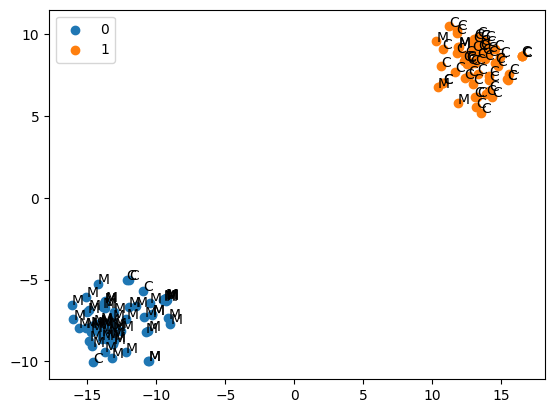

In [72]:
predictionModule.bench.plot(embeddingMatrix,
                            ["C" if x==1 else "M" for x in clusteringResults[1]],
                            clusteringResults[2])

In [81]:
from sklearn.metrics import silhouette_score

# Step 1: Separate the features and the labels
features = embeddingMatrix[:, :-1]  # all columns except last
labels = embeddingMatrix[:, -1]     # last column

# Step 2: Compute silhouette score
score = silhouette_score(features, labels)
print(f"Silhouette Score: {score:.4f}")


Silhouette Score: 0.0653


In [80]:
embeddingMatrix

array([[ 2.22444675e-02,  3.51812232e-02, -9.87315946e-02, ...,
        -5.67138600e-02, -7.66628222e-02,  1.99166667e+01],
       [ 1.65657461e-02, -1.80134766e-02, -2.79585769e-02, ...,
        -1.33455509e-01, -1.21066353e-02,  1.99166667e+01],
       [-3.54533200e-02, -6.14845965e-02, -1.70936608e-01, ...,
        -9.38423125e-02,  3.27760562e-01,  1.99166667e+01],
       ...,
       [-7.86285250e-02, -4.03873376e-02, -5.18607270e-02, ...,
        -1.03471085e-01,  4.31978953e-02,  2.24166667e+01],
       [-1.15932785e-01, -2.29005536e-02, -3.28806300e-02, ...,
        -4.97607418e-02,  1.52865253e-01,  2.24166667e+01],
       [ 7.00434252e-02, -1.50822327e-01, -3.54906424e-02, ...,
        -5.35635173e-02, -1.71332218e-02,  2.24166667e+01]])

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_dataset_embedding(embeddingMatrix, dataset_labels, apply_pca=False, apply_tsne=True, pca_random_state=1):
    """
    Plot 2D embedding of observations colored by dataset (e.g., Monkeypox vs COVID).

    Parameters:
    - embeddingMatrix: np.ndarray
    - dataset_labels: list or np.ndarray of 0 (Monkeypox) or 1 (COVID)
    - apply_pca / apply_tsne: bool
    - pca_random_state: int
    """
    if apply_pca:
        pca = PCA(n_components=2, random_state=pca_random_state)
        matrix = pca.fit_transform(embeddingMatrix)
    elif apply_tsne:
        perplexity = max(5, min(30, embeddingMatrix.shape[0] // 3))
        tsne = TSNE(n_components=2, random_state=pca_random_state)
        matrix = tsne.fit_transform(embeddingMatrix)
    else:
        matrix = embeddingMatrix

    matrix = np.array(matrix)
    dataset_labels = np.array(dataset_labels)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_facecolor("white")

    # Colors and labels
    colors = {0: 'royalblue', 1: 'orangered'}
    labels_text = {0: 'Monkeypox-Dataset', 1: 'COVID-Dataset'}

    for label in np.unique(dataset_labels):
        points = matrix[dataset_labels == label]
        ax.scatter(points[:, 0], points[:, 1],
                   color=colors[label],
                   label=labels_text[label],
                   s=150,
                   alpha=0.9,
                   edgecolor='black')

    # Legend
    ax.legend(fontsize=14, frameon=True, markerscale=1.5)
    ax.set_xlabel("X", fontsize=14)
    ax.set_ylabel("Y", fontsize=14)
    ax.set_title("Embedding per Dataset", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


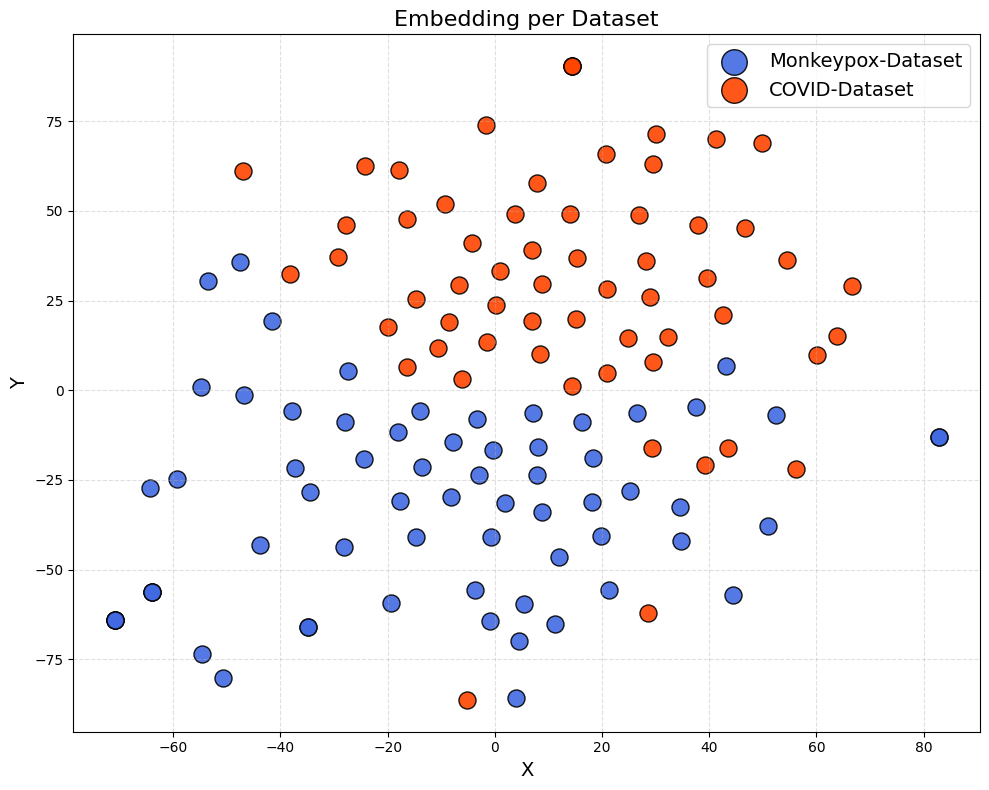

In [79]:
plot_dataset_embedding(embeddingMatrix2, clusteringResults[2])

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def myplot(embeddingMatrix, legend_list, labels, apply_pca=False, apply_tsne=True, pca_random_state=1):
    if apply_pca:
        pca = PCA(2, random_state=pca_random_state)
        matrix = pca.fit_transform(embeddingMatrix)
    elif apply_tsne:
        perplexity = max(5, min(30, embeddingMatrix.shape[0] // 3))
        tsne = TSNE(n_components=2, random_state=pca_random_state)
        matrix = tsne.fit_transform(embeddingMatrix)
    else:
        matrix = embeddingMatrix

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = {0: 'royalblue', 1: 'orangered'}  # 0 = Monkeypox, 1 = COVID
    markers = {'M': 'o', 'C': 's'}             # M = Monkeypox, C = COVID predictions

    for idx in range(len(matrix)):
        x, y = matrix[idx]
        dataset_label = labels[idx]
        prediction_label = legend_list[idx]
        ax.scatter(x, y,
                   color=colors[dataset_label],
                   marker=markers[prediction_label],
                   alpha=0.7,
                   edgecolor='black',
                   s=150)  # Large points

        ax.text(x, y, prediction_label, fontsize=10, ha='center', va='center', color='black', weight='bold')  # Black letters

    # Custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Monkeypox (dataset)',
               markerfacecolor='royalblue', markersize=20, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='COVID (dataset)',
               markerfacecolor='orangered', markersize=20, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='black', label='Predicted M (Monkeypox)', markersize=20),
        Line2D([0], [0], marker='s', color='black', label='Predicted C (COVID)', markersize=20),
    ]
    legend = ax.legend(handles=legend_elements, loc='best', fontsize=16, frameon=True, framealpha=0.95)
    legend.get_frame().set_linewidth(1.5)
    #ax.set_title("2D Embedding of Observations with Predictions", fontsize=16)
    ax.set_xlabel("X", fontsize=14)
    ax.set_ylabel("Y", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


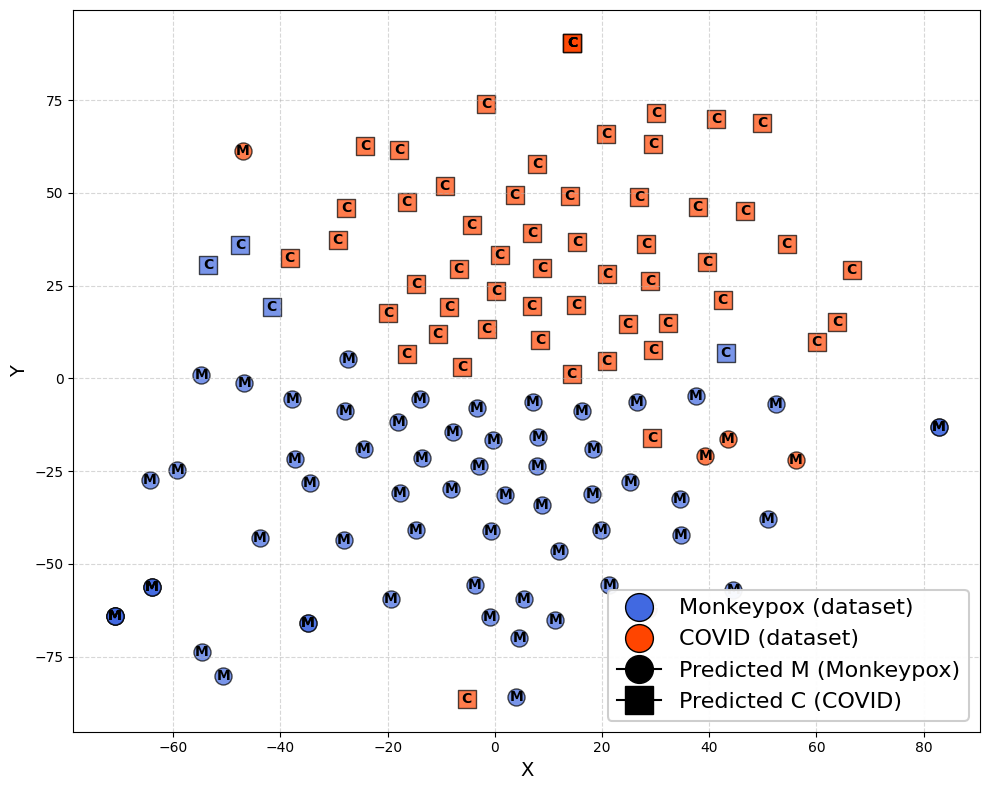

In [76]:
myplot(
    embeddingMatrix2, 
    ["C" if x == 1 else "M" for x in clusteringResults[1]],
    clusteringResults[2]
)

In [59]:
re = "SentenceMatching"
score = 0
studiedRE = predictionModule.re_dict[re]
embeddingMatrix = predictionModule.dict_embedders[embedders].applyEmbedding(studiedRE,df_kb, df_net,
                                                                          include_spatial=True,
                                                                           include_temporal=True)

In [60]:
cluter_method = 'K-Means'
print("Benchmark for " + str((re, embedders, cluter_method)))
clusteringResults = predictionModule.dict_clusteres[cluter_method].applyClustering(embeddingMatrix, studiedRE)
score = clusteringResults[0]
predictionModule.bench.dict_bench[(re, embedders, cluter_method)] = score

Benchmark for ('SentenceMatching', 'FastRP-average', 'K-Means')


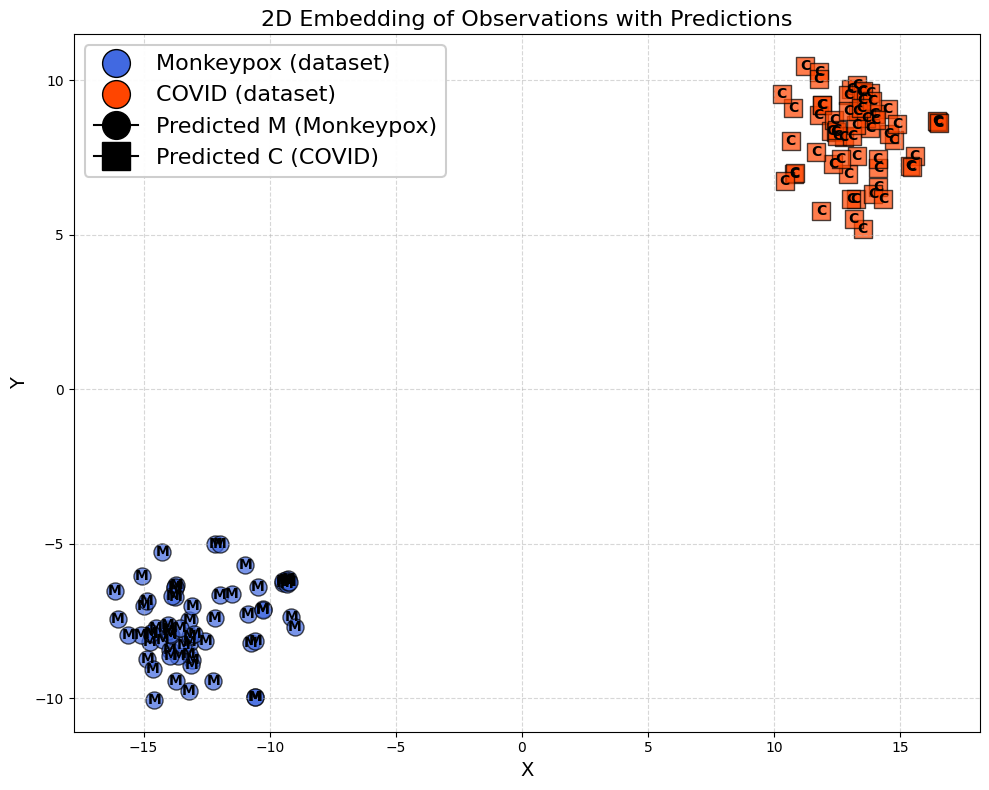

In [68]:
myplot(
    embeddingMatrix, 
    ["C" if x == 1 else "M" for x in clusteringResults[1]],
    clusteringResults[2]
)

### 2-Spatial Non temporal Embedding

In [ ]:
predictionModule.bench = BenchMark()
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=True,
                                  include_temporal=False)
predictionModule.RunBenchMark(include_spatial=True,
                                  include_temporal=False)

In [ ]:
# For (all observations, considering space, considering type):
predictionModule.bench.dict_bench

### 3-Temporal Non Spatio Embedding

In [ ]:
predictionModule.bench = BenchMark()
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=False,
                                  include_temporal=True)
predictionModule.RunBenchMark(include_spatial=False,
                                  include_temporal=True)

In [ ]:
# For (all observations, considering space, considering type):
predictionModule.bench.dict_bench

### 4- Spatiotemporal Embedding

In [ ]:
predictionModule.bench = BenchMark()
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=True,
                                  include_temporal=True)
predictionModule.RunBenchMark(include_spatial=True,
                                  include_temporal=True)

In [ ]:
# For (all observations, considering space, considering type):
predictionModule.bench.dict_bench

## W.H.O. Confirmed Observations

### WHO.1- No Spatiotemporal Embedding

In [20]:
neowrapper = Neo4jWrapper(uri="bolt://localhost:7687",userName="neo4j",password="test")

In [21]:
# Run to garante cases in those dates
strQueryChinaNov = """
MATCH (startNode:CUI {id: 'C5203670'}), (endNode:Country {id:'wkg:424313582'})
MERGE (startNode)-[relation:isReported {date: '2019-11-01'}]->(endNode)
ON CREATE SET relation.date = '2019-11-01'
"""

strQueryChinaDec = """
MATCH (startNode:CUI {id: 'C5203670'}), (endNode:Country {id:'wkg:424313582'})
MERGE (startNode)-[relation:isReported {date: '2019-12-01'}]->(endNode)
ON CREATE SET relation.date = '2019-12-01'
"""

result = neowrapper.sendQuery([strQueryChinaNov, strQueryChinaDec])

100%|█████████████████████████████████████████████| 2/2 [00:13<00:00,  6.99s/it]


In [ ]:
predictionModule.bench = BenchMark()
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=False,
                                  include_temporal=False,filtered=True,
                                  neowrapper=neowrapper)

In [26]:
predictionModule.RunBenchMark(include_spatial=False,
                                  include_temporal=False,filtered=True,
                                  neowrapper=neowrapper)

Setting up for BoW
Loading BoW embeddings...
Loaded 12620098 KB gazetteer entries and 1692483 network gazetteer entries.


100%|█████████████████████████████████████████████| 1/1 [00:03<00:00,  3.68s/it]
54it [00:00, 6842.46it/s]


Benchmark for ('DocumentMatching', 'BoW', 'K-Means')


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.40it/s]
2it [00:00, 2446.37it/s]
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in la

Benchmark for ('ParagraphMatching', 'BoW', 'K-Means')


...

Observation embeddings computed successfully.
Benchmark for ('ParagraphMatching', 'RelTopicEmbedding-average', 'K-Means')


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.36it/s]


Loading KB distances from ../data/prediction/embeddings/semantic/dijkstra.csv...
Loading data from ../data/prediction/embeddings/semantic/dijkstra.csv...
Created DataFrame with 127 concepts.
Loading KB neighborhood data from ../data/prediction/embeddings/semantic/neighborhood.csv...
Loading KB special degree data from ../data/prediction/embeddings/semantic/specialdegree.csv...
Processing complete. Computing aggregated embeddings for observations...


100%|███████████████████████████████████████████| 32/32 [06:06<00:00, 11.45s/it]


Observation embeddings computed successfully.
Benchmark for ('SentenceMatching', 'RelTopicEmbedding-average', 'K-Means')


In [27]:
predictionModule.bench.dict_bench

{('DocumentMatching', 'Wang', 'K-Medoids'): 0.761992126285212,
 ('ParagraphMatching', 'Wang', 'K-Medoids'): 0.6666666666666666,
 ('SentenceMatching', 'Wang', 'K-Medoids'): 0.7333333333333334,
 ('DocumentMatching', 'BoW', 'K-Means'): 0.9056098351873,
 ('ParagraphMatching', 'BoW', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'BoW', 'K-Means'): 0.5636363636363637,
 ('DocumentMatching', 'Node2Vec-sum', 'K-Means'): 0.8835894718247659,
 ('ParagraphMatching', 'Node2Vec-sum', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'Node2Vec-sum', 'K-Means'): 0.4817813765182186,
 ('DocumentMatching', 'FastRP-sum', 'K-Means'): 0.9039646299920273,
 ('ParagraphMatching', 'FastRP-sum', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'FastRP-sum', 'K-Means'): 0.5333333333333333,
 ('DocumentMatching', 'Node2Vec-average', 'K-Means'): 0.464325797659131,
 ('ParagraphMatching', 'Node2Vec-average', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'Node2Vec-average', 'K-Means'): 0.5134502

### WHO.2- Spatiotemporal Embedding

In [28]:
predictionModule.bench = BenchMark()
predictionModule.RunWangBenchMark(kb_concept_path,net_concept_path,
                        kb_sa_path, net_sa_path,
                        kb_sva_path, net_sva_path,include_spatial=True,
                                  include_temporal=True,filtered=True,
                                  neowrapper=neowrapper)
predictionModule.RunBenchMark(include_spatial=True,
                                  include_temporal=True,filtered=True,
                                  neowrapper=neowrapper)

Loading concept mappings from ../data/prediction/embeddings/semantic/semantic_types_export.csv and ../data/prediction/embeddings/semantic/world_semantic_type.csv...
Loading semantic annotations (SA) and semantic value annotations (SVA)...
DataFrames loaded successfully.


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.59it/s]


Benchmark for ('DocumentMatching', 'Wang', 'K-Medoids')
Processing KB concepts...
Processing Network concepts...
Processing complete. Computing embeddings for observations...


100%|███████████████████████████████████████████| 54/54 [18:29<00:00, 20.54s/it]


Observation embeddings computed successfully.
Clustering observations with k-medoids...
Evaluating clustering...
Clustering completed. Best F1 Score: 0.8724


...

Observation embeddings computed successfully.
Benchmark for ('ParagraphMatching', 'RelTopicEmbedding-average', 'K-Means')


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.54it/s]


Loading KB distances from ../data/prediction/embeddings/semantic/dijkstra.csv...
Loading data from ../data/prediction/embeddings/semantic/dijkstra.csv...
Created DataFrame with 127 concepts.
Loading KB neighborhood data from ../data/prediction/embeddings/semantic/neighborhood.csv...
Loading KB special degree data from ../data/prediction/embeddings/semantic/specialdegree.csv...
Loading Network distances from ../data/prediction/embeddings/semantic/world_dijkstra.csv...
Loading data from ../data/prediction/embeddings/semantic/world_dijkstra.csv...
Created DataFrame with 9 concepts.
Loading Network neighborhood data from ../data/prediction/embeddings/semantic/world_neighborhood.csv...
Loading Network special degree data from ../data/prediction/embeddings/semantic/world_special_degree.csv...
Processing complete. Computing aggregated embeddings for observations...


100%|███████████████████████████████████████████| 32/32 [06:04<00:00, 11.38s/it]


Observation embeddings computed successfully.
Benchmark for ('SentenceMatching', 'RelTopicEmbedding-average', 'K-Means')


In [29]:
predictionModule.bench.dict_bench

{('DocumentMatching', 'Wang', 'K-Medoids'): 0.8724279835390947,
 ('ParagraphMatching', 'Wang', 'K-Medoids'): 0.6666666666666666,
 ('SentenceMatching', 'Wang', 'K-Medoids'): 0.9687194525904204,
 ('DocumentMatching', 'BoW', 'K-Means'): 0.9238683127572016,
 ('ParagraphMatching', 'BoW', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'BoW', 'K-Means'): 1.0,
 ('DocumentMatching', 'Node2Vec-sum', 'K-Means'): 0.5808348030570253,
 ('ParagraphMatching', 'Node2Vec-sum', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'Node2Vec-sum', 'K-Means'): 0.5307917888563051,
 ('DocumentMatching', 'FastRP-sum', 'K-Means'): 0.9039646299920273,
 ('ParagraphMatching', 'FastRP-sum', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'FastRP-sum', 'K-Means'): 0.5333333333333333,
 ('DocumentMatching', 'Node2Vec-average', 'K-Means'): 1.0,
 ('ParagraphMatching', 'Node2Vec-average', 'K-Means'): 0.6666666666666666,
 ('SentenceMatching', 'Node2Vec-average', 'K-Means'): 0.9687194525904204,
 ('DocumentMat